In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

In [15]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Train:", x_train.shape)
print("Test :", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2144s 13us/step
Train: (50000, 32, 32, 3)
Test : (10000, 32, 32, 3)


In [16]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

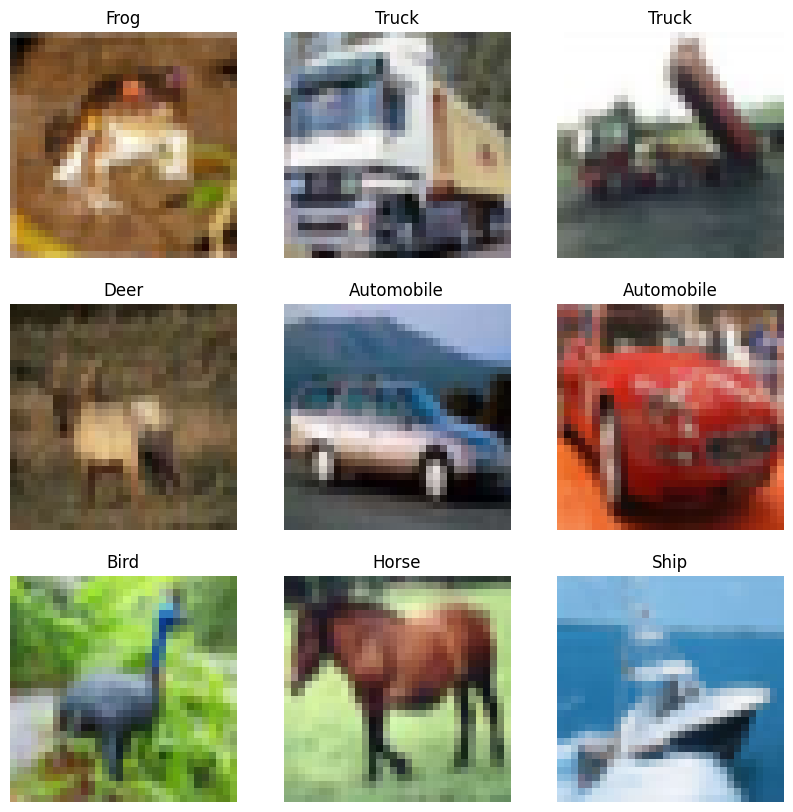

In [17]:
classes = [
    "Airplane","Automobile","Bird","Cat","Deer",
    "Dog","Frog","Horse","Ship","Truck"
]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(classes[np.argmax(y_train[i])])
    plt.axis("off")

plt.show()

In [18]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(256,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 99ms/step - accuracy: 0.3705 - loss: 1.6960 - val_accuracy: 0.5174 - val_loss: 1.3417
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 98ms/step - accuracy: 0.5349 - loss: 1.2959 - val_accuracy: 0.5736 - val_loss: 1.1973
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.5934 - loss: 1.1458 - val_accuracy: 0.6271 - val_loss: 1.0577
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 96ms/step - accuracy: 0.6374 - loss: 1.0302 - val_accuracy: 0.6474 - val_loss: 0.9943
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.6691 - loss: 0.9417 - val_accuracy: 0.6546 - val_loss: 0.9945
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.6888 - loss: 0.8783 - val_accuracy: 0.6868 - val_loss: 0.8969
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 97ms/step - accuracy: 0.7178 - loss: 0.8108 - val_accuracy: 0.7053 - val_loss: 0.8619
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 97ms/step - accuracy: 0.7354 - loss: 0.7596 - 

In [21]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7311 - loss: 0.9389
Loss: 0.9388704895973206
Accuracy: 0.7311000227928162


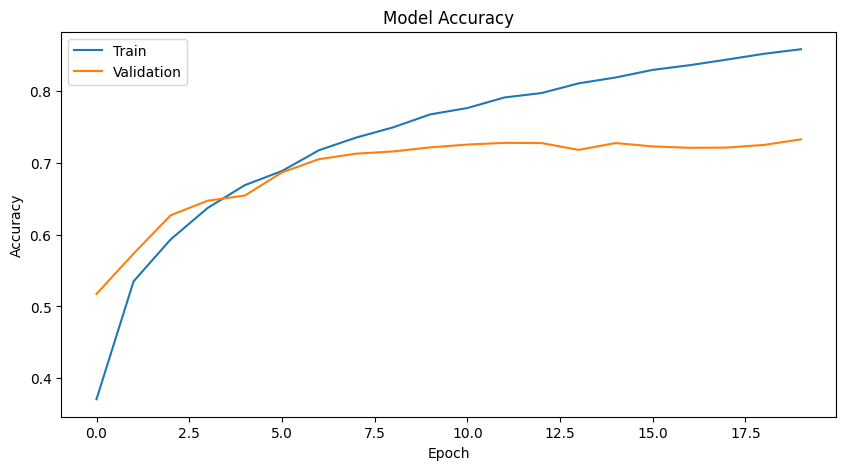

In [22]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")

plt.legend()

plt.show()

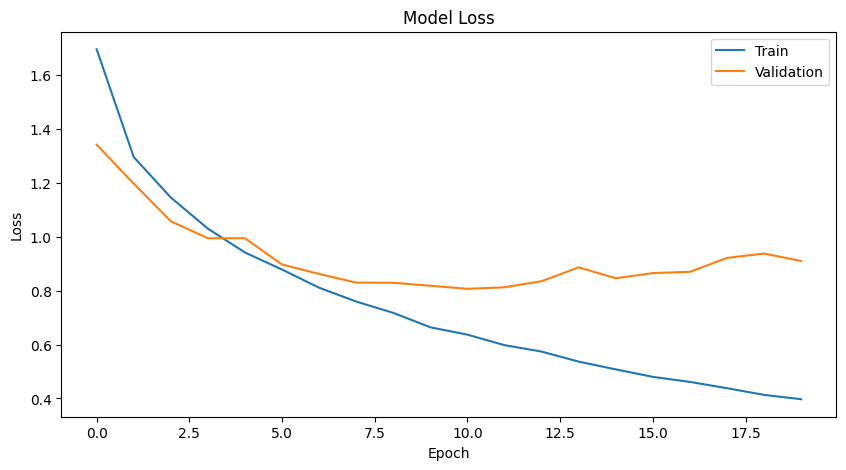

In [23]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")

plt.legend()

plt.show()

In [24]:
prediction = model.predict(x_test)

pred = np.argmax(prediction, axis=1)

true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


In [25]:
print(classification_report(true, pred))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76      1000
           1       0.89      0.82      0.85      1000
           2       0.61      0.65      0.63      1000
           3       0.56      0.57      0.56      1000
           4       0.67      0.72      0.69      1000
           5       0.65      0.61      0.63      1000
           6       0.83      0.78      0.80      1000
           7       0.77      0.75      0.76      1000
           8       0.81      0.84      0.82      1000
           9       0.78      0.83      0.81      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.73      0.73     10000



In [26]:
cm = confusion_matrix(true, pred)

print(cm)

[[756  17  57  16   6   5   8  18  83  34]
 [ 22 817  10   9   4   3   7   4  37  87]
 [ 61   3 648  70  80  49  40  24  15  10]
 [ 11   7  83 569  75 143  42  32  12  26]
 [ 14   2  80  51 716  28  30  65  11   3]
 [ 11   3  70 173  49 610  22  54   3   5]
 [  6   5  52  62  45  28 779   6   8   9]
 [ 15   1  30  45  69  61   5 747   6  21]
 [ 61  16  15  12  12   2   3   6 837  36]
 [ 35  47  10  18   5   8   6  12  27 832]]
